## 4. Polynomial Regression (Quadratic)

### Theory

Polynomial regression fits a polynomial curve to the data.

**Model Equation (Degree 2 - Quadratic):**

$$y = a + bx + cx^2$$

**Objective Function:**

Minimize the sum of squared residuals:

$$S = \sum_{i=1}^{n} (y_i - (a + bx_i + cx_i^2))^2$$

**Normal Equations:**

Taking partial derivatives with respect to $a$, $b$, and $c$:

$$\frac{\partial S}{\partial a} = -2\sum_{i=1}^{n} (y_i - a - bx_i - cx_i^2) = 0$$

$$\frac{\partial S}{\partial b} = -2\sum_{i=1}^{n} x_i(y_i - a - bx_i - cx_i^2) = 0$$

$$\frac{\partial S}{\partial c} = -2\sum_{i=1}^{n} x_i^2(y_i - a - bx_i - cx_i^2) = 0$$

This yields the system:

$$
\begin{cases}
na + b\sum x_i + c\sum x_i^2 = \sum y_i \\[2ex]
a\sum x_i + b\sum x_i^2 + c\sum x_i^3 = \sum x_i y_i \\[2ex]
a\sum x_i^2 + b\sum x_i^3 + c\sum x_i^4 = \sum x_i^2 y_i
\end{cases}
$$

**Matrix Form:**

$$
\begin{bmatrix}
n & \sum x_i & \sum x_i^2 \\
\sum x_i & \sum x_i^2 & \sum x_i^3 \\
\sum x_i^2 & \sum x_i^3 & \sum x_i^4
\end{bmatrix}
\begin{bmatrix}
a \\ b \\ c
\end{bmatrix}
=
\begin{bmatrix}
\sum y_i \\ \sum x_i y_i \\ \sum x_i^2 y_i
\end{bmatrix}
$$

**Solution:**

$$\beta = (X^T X)^{-1} X^T Y$$

Where $X$ is the Vandermonde matrix:

$$
X = \begin{bmatrix}
1 & x_1 & x_1^2 \\
1 & x_2 & x_2^2 \\
\vdots & \vdots & \vdots \\
1 & x_n & x_n^2
\end{bmatrix}
$$

**Algorithm:**

1. Create matrix $X$ with dimensions $n \times 3$:
   - $X[i][0] = 1$
   - $X[i][1] = x_i$
   - $X[i][2] = x_i^2$
2. Compute $X^T X$ and $X^T Y$
3. Solve $(X^T X) \beta = X^T Y$ for $\beta$
4. Return coefficients $(a, b, c)$

POLYNOMIAL LEAST SQUARE
Degree: 2 (Quadratic)

Fitted quadratic: y = 0.0000 + -0.0000 x + 1.0000 x²
R² = 1.0000


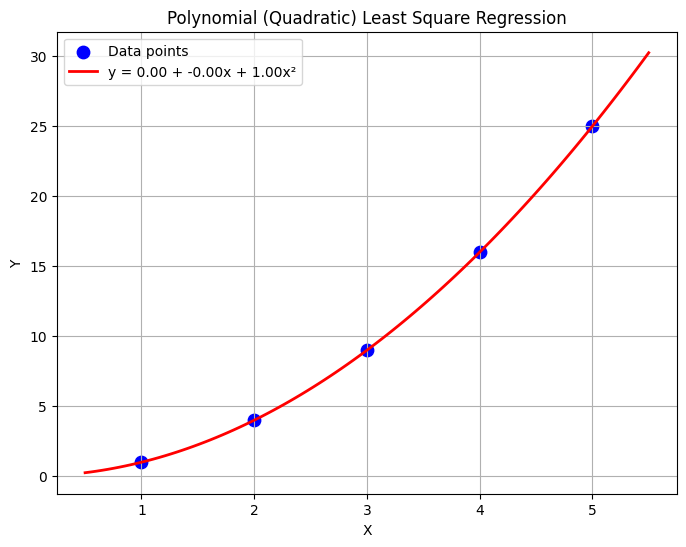

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Polynomial Least Square (Quadratic: y = a + b*x + c*x²)
x = np.array([1, 2, 3, 4, 5], dtype=np.float32)
y = np.array([1, 4, 9, 16, 25], dtype=np.float32)  # Perfect quadratic

n = len(x)
degree = 2

print("=" * 40)
print("POLYNOMIAL LEAST SQUARE")
print("=" * 40)
print(f"Degree: {degree} (Quadratic)")

# Calculate sums needed for normal equations
sumx = 0
sumx2 = 0
sumx3 = 0
sumx4 = 0
sumy = 0
sumxy = 0
sumx2y = 0

for i in range(n):
    sumx += x[i]
    sumx2 += x[i]**2
    sumx3 += x[i]**3
    sumx4 += x[i]**4
    sumy += y[i]
    sumxy += x[i] * y[i]
    sumx2y += (x[i]**2) * y[i]

# Normal equations for quadratic: y = a + b*x + c*x²
# [ n      sumx    sumx2  ] [a] = [ sumy  ]
# [ sumx   sumx2   sumx3  ] [b] = [ sumxy ]
# [ sumx2  sumx3   sumx4  ] [c] = [ sumx2y]

# Create matrix and solve
A = np.array([
    [n, sumx, sumx2],
    [sumx, sumx2, sumx3],
    [sumx2, sumx3, sumx4]
])

B = np.array([sumy, sumxy, sumx2y])

# Solve using matrix inversion
coeff = np.linalg.solve(A, B)
a, b, c = coeff

print(f"\nFitted quadratic: y = {a:.4f} + {b:.4f} x + {c:.4f} x²")

# Calculate predicted values
y_pred = a + b * x + c * x**2

# Calculate R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)
print(f"R² = {r2:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', s=80, label='Data points')

x_curve = np.linspace(min(x)-0.5, max(x)+0.5, 100)
y_curve = a + b * x_curve + c * x_curve**2
plt.plot(x_curve, y_curve, color='red', linewidth=2, 
         label=f'y = {a:.2f} + {b:.2f}x + {c:.2f}x²')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Polynomial (Quadratic) Least Square Regression')
plt.legend()
plt.grid(True)
plt.show()